In [2]:
import os
import getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
plt.style.use("ggplot")

In [ ]:
os.environ["KAGGLE_USERNAME"] = input("Username: ")
os.environ["KAGGLE_KEY"] = getpass.getpass("API Key: ")
!pip install -q kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
kaggle = KaggleApi()
kaggle.authenticate()
dataset = "pavansubhasht/ibm-hr-analytics-attrition-dataset"
kaggle.dataset_download_files(
    dataset=dataset,
    path="./",
    unzip=True
)
print("Dataset download is successful.")

In [5]:
#Task1
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
#Task1
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features:")
print(numerical_features)
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:")
print(categorical_features)
target_variable = "Attrition"
print("Target Variable:", target_variable)
print("\nTarget Variable Distribution:")
print(df[target_variable].value_counts())

Numerical Features:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical Features:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Target Variable: Attrition

Target Variable Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [8]:
#Task1
print("Dataset Information:\n")
df.info()


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  Jo

In [9]:
#Task1
print("Summary Statistics:")
df.describe()

Summary Statistics:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
#Task2
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [11]:
#Task2
drop_cols = [
    'EmployeeCount',
    'Over18',
    'StandardHours'
]
df.drop(columns=drop_cols, inplace=True)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2


In [12]:
#Task2
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,7,1,...,3,4,1,6,3,3,2,2,2,2


In [13]:
#Task2
X = df.drop("Attrition", axis=1)
y = df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(1176, 31)
(294, 31)


In [14]:
#Task3
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [15]:
#Task3
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [17]:
#Task3
prediction_df = X_test.copy()
prediction_df["Actual Attrition"] = y_test.values
prediction_df["Decision Tree Prediction"] = dt_pred
prediction_df["Random Forest Prediction"] = rf_pred
prediction_df.head(10)

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Actual Attrition,Decision Tree Prediction,Random Forest Prediction
1061,24,0,830,2,13,2,1,1495,4,0,...,1,2,3,1,0,0,0,0,0,1
891,44,2,1117,1,2,1,1,1246,1,0,...,10,5,3,10,5,7,7,0,0,0
456,31,2,688,2,7,3,1,613,3,1,...,10,3,2,5,4,0,1,0,0,0
922,44,2,1199,1,4,2,1,1288,3,1,...,26,4,2,25,9,14,13,0,0,0
69,36,2,318,1,9,3,3,90,4,1,...,2,0,2,1,0,0,0,1,1,0
1164,40,2,448,1,16,3,1,1641,3,0,...,18,2,2,4,2,3,3,0,0,0
406,52,2,319,1,3,3,3,543,4,1,...,28,4,3,5,4,0,4,0,0,0
1330,43,2,823,1,6,3,3,1866,1,0,...,21,2,3,16,12,6,14,0,0,0
1232,35,2,1370,1,27,4,1,1728,4,1,...,17,3,3,7,7,0,7,0,0,0
1311,18,0,1431,1,14,3,3,1839,2,0,...,0,4,1,0,0,0,0,0,0,1


In [18]:
#Task4
def evaluate(y_true, pred):
    print("Accuracy :", accuracy_score(y_true, pred))
    print("Precision :", precision_score(y_true, pred))
    print("Recall :", recall_score(y_true, pred))
    print("F1 Score :", f1_score(y_true, pred))
    print("\nClassification Report\n")
    print(classification_report(y_true, pred))

In [19]:
#Task4
print("Decision Tree Performance\n")
evaluate(y_test, dt_pred)

Decision Tree Performance

Accuracy : 0.7585034013605442
Precision : 0.29310344827586204
Recall : 0.3617021276595745
F1 Score : 0.3238095238095238

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       247
           1       0.29      0.36      0.32        47

    accuracy                           0.76       294
   macro avg       0.58      0.60      0.59       294
weighted avg       0.78      0.76      0.77       294



In [20]:
#Task4
print("Random Forest Performance\n")
evaluate(y_test, rf_pred)

Random Forest Performance

Accuracy : 0.8333333333333334
Precision : 0.42857142857142855
Recall : 0.1276595744680851
F1 Score : 0.19672131147540983

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.43      0.13      0.20        47

    accuracy                           0.83       294
   macro avg       0.64      0.55      0.55       294
weighted avg       0.79      0.83      0.79       294



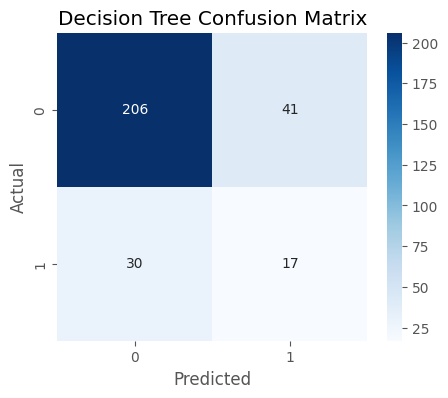

In [21]:
#Task4
cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

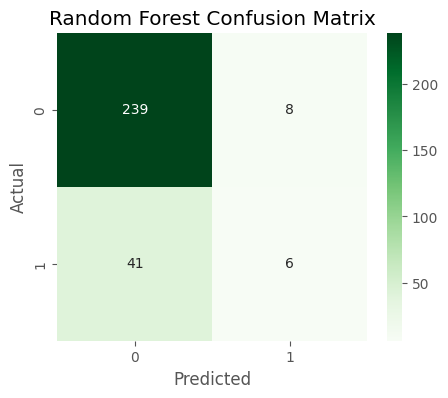

In [22]:
#Task4
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

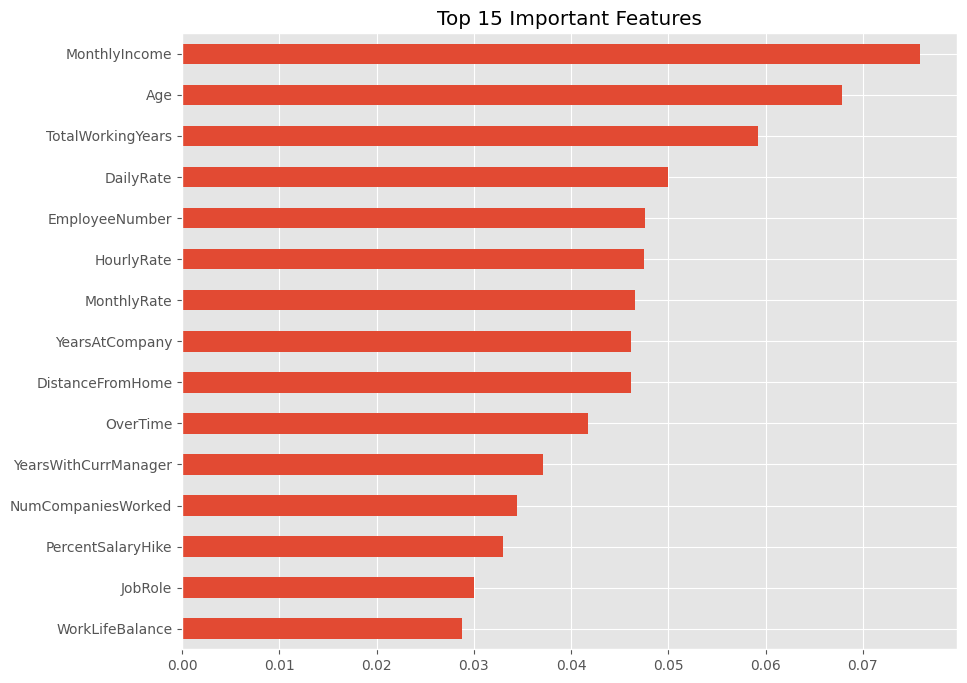

In [23]:
#Task4
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)
importance = importance.sort_values(ascending=False)
plt.figure(figsize=(10,8))
importance.head(15).plot(kind='barh')
plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [24]:
#Task4
comparison = pd.DataFrame({
    "Model":["Decision Tree","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision":[
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall":[
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score":[
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.758503,0.293103,0.361702,0.323810
1,Random Forest,0.833333,0.428571,0.127660,0.196721


# Task 4

1. Random Forest achieved higher overall accuracy (83.33%) than the Decision Tree (75.85%), indicating that it classified a greater proportion of employees correctly.

2. The Decision Tree model performed better in identifying employees who are likely to leave the company, achieving a higher Recall (36.17%) and F1-score (32.38%) compared to the Random Forest model (Recall: 12.77%, F1-score: 19.67%). This means the Decision Tree detected more actual attrition cases.

3. The Random Forest model produced fewer false positives (8) than the Decision Tree (41), showing that it was more conservative and made fewer incorrect predictions that an employee would leave.

4. The Random Forest confusion matrix shows a larger number of false negatives (41) than the Decision Tree (30). As a result, Random Forest missed more employees who actually left the organization, whereas the Decision Tree provided a better balance between identifying attrition cases and overall performance.

#Task 5
#Conclusion

In this assignment, both the Decision Tree and Random Forest classifiers were developed to predict employee attrition using the IBM HR Analytics dataset. Based on the evaluation results, the Random Forest model performed better overall, achieving a higher accuracy of 83.33% and better precision than the Decision Tree. This indicates that Random Forest made more correct predictions overall and produced fewer false positive predictions. However, the Decision Tree achieved higher recall and F1-score, making it more effective at identifying employees who were actually likely to leave the organization.

Random Forest often outperforms a single Decision Tree because it combines the predictions of multiple decision trees using an ensemble approach. This reduces overfitting, improves generalization, and produces more stable and reliable predictions on unseen data.

One limitation of the Decision Tree is that it is prone to overfitting, especially when the tree becomes very deep, which can reduce its performance on new data. A limitation of Random Forest is that it is computationally more expensive and less interpretable than a single Decision Tree due to the large number of trees used in the model.